<a href="https://colab.research.google.com/github/Shuvo3128/A-Comparative-and-Explainable-Hybrid-Framework-for-Sentiment-Classification-/blob/main/Feature_extraction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn nltk spacy tensorflow transformers

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Dataset/IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


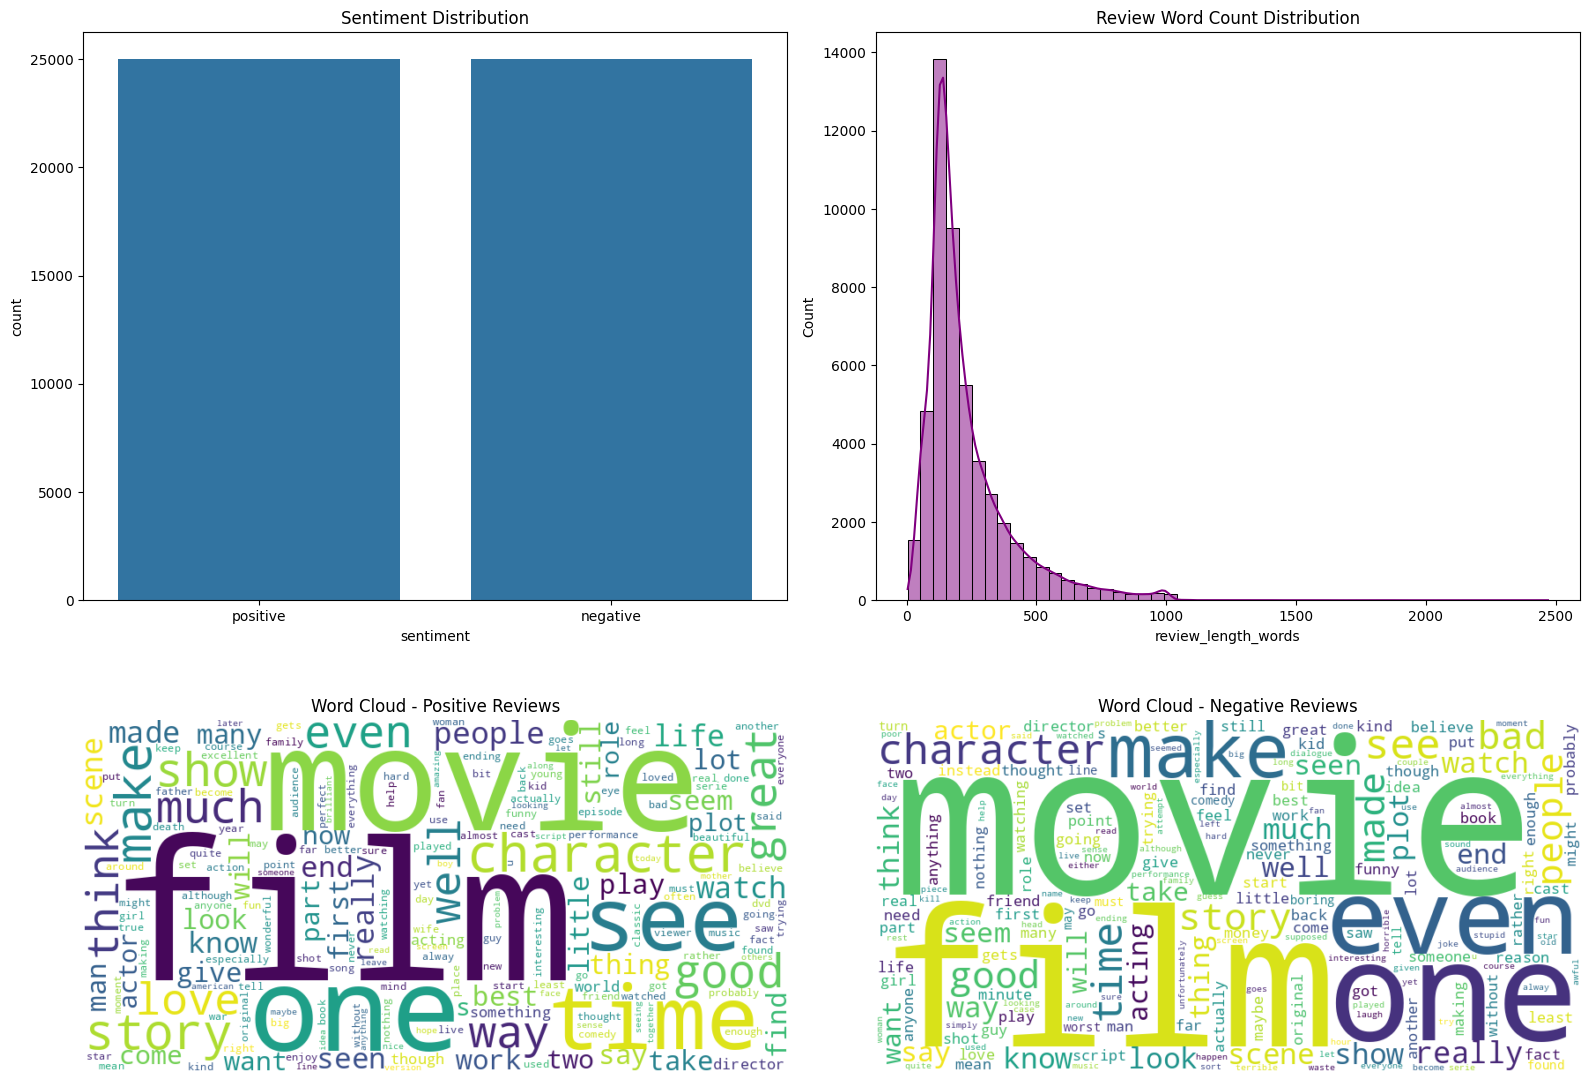

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
from wordcloud import WordCloud

# Load dataset using 'quotechar' and 'escapechar'
df = pd.read_csv(
    '/content/drive/MyDrive/Dataset/IMDB Dataset.csv',
    escapechar='\\',
    quotechar='"',
    engine='python',
    on_bad_lines='skip', # Skip problematic lines
    dtype={'review': str, 'sentiment': str} # Specify data types
)
# Basic overview
print("Dataset shape:", df.shape)
print(df.head())

# Add word count feature
df['review_length_words'] = df['review'].apply(lambda x: len(str(x).split()))

# Function to clean reviews (remove HTML, punctuation, lowercase)
def clean_review(text):
    text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML tags
    text = re.sub(r"[^a-zA-Z']", ' ', text)  # Remove punctuation/numbers
    text = text.lower()  # Convert to lowercase
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_review)

# Split positive and negative reviews
positive_text = " ".join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_text = " ".join(df[df['sentiment'] == 'negative']['cleaned_review'])

# === Plotting ===
plt.figure(figsize=(16, 12))

# 1. Sentiment Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution")

# 2. Review Word Count
plt.subplot(2, 2, 2)
sns.histplot(df['review_length_words'], bins=50, kde=True, color='purple')
plt.title("Review Word Count Distribution")

# 3. Word Cloud - Positive
plt.subplot(2, 2, 3)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Positive Reviews")

# 4. Word Cloud - Negative
plt.subplot(2, 2, 4)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Negative Reviews")

plt.tight_layout()
plt.show()

In [ ]:
!pip install nltk spacy
!python -m nltk.downloader stopwords punkt wordnet
!python -m spacy download en_core_web_sm

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import spacy

# Download NLTK data (run once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Load SpaCy for lemmatization
nlp = spacy.load("en_core_web_sm")

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Dataset/IMDB Dataset.csv")

# Initialize
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Strong preprocessing function
def preprocess_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.lower()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize using SpaCy
    doc = nlp(" ".join(tokens))
    lemmatized = [token.lemma_ for token in doc if token.lemma_ != '-PRON-']

    return " ".join(lemmatized).strip()

# Apply preprocessing
df["cleaned_review"] = df["review"].apply(preprocess_text)

# Preview
print(df[["review", "cleaned_review"]].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mention watch oz episode you ll h...  
1  wonderful little production filming technique ...  
2  think wonderful way spend time hot summer week...  
3  basically there s family little boy jake think...  
4  petter matteis love time money visually stunni...  


In [ ]:
# Save to CSV (recommended for compatibility)
df.to_csv('/content/drive/MyDrive/Dataset/IMDB_Cleaned.csv', index=False)

# Optional: Save to Pickle (preserves object types like lists, etc.)
df.to_pickle('/content/drive/MyDrive/Dataset/IMDB_Cleaned.pkl')


In [ ]:
# Load the cleaned version
df = pd.read_csv('/content/drive/MyDrive/Dataset/IMDB_Cleaned.csv')

# Or if you used Pickle:
# df = pd.read_pickle('/content/drive/MyDrive/Dataset/IMDB_Cleaned.pkl')

# Quick check
print(df.head())


                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      cleaned_review  
0  one reviewer mention watch oz episode you ll h...  
1  wonderful little production filming technique ...  
2  think wonderful way spend time hot summer week...  
3  basically there s family little boy jake think...  
4  petter matteis love time money visually stunni...  


In [ ]:
# ------------------------------------------------------------
# 0) Imports (add numpy)
# ------------------------------------------------------------
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification, create_optimizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
import pandas as pd
import numpy as np
import gc          # for memory clean‑up

# ------------------------------------------------------------
# 1) Load / prepare data (unchanged)
# ------------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/Dataset/IMDB Dataset.csv")

text_column = "cleaned_review" if "cleaned_review" in df.columns else "review"
texts  = df[text_column].astype(str).tolist()
labels = (df["sentiment"] == "positive").astype(int).tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(texts, max_len=256):
    return tokenizer(texts, truncation=True, padding=True, max_length=max_len)

train_enc  = tokenize(train_texts)
val_enc    = tokenize(val_texts)

train_ds = tf.data.Dataset.from_tensor_slices((dict(train_enc), train_labels)).batch(16)
val_ds   = tf.data.Dataset.from_tensor_slices((dict(val_enc),   val_labels)).batch(16)

# ------------------------------------------------------------
# 2) Model, optimiser, training (unchanged)
# ------------------------------------------------------------
model = TFDistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

num_steps = len(train_ds) * 3
optimizer, lr_schedule = create_optimizer(
    init_lr=3e-5, num_train_steps=num_steps, num_warmup_steps=0
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

history = model.fit(train_ds, validation_data=val_ds, epochs=3)

loss, acc = model.evaluate(val_ds)
print(f"Validation accuracy: {acc:.4f}")

pred_logits = model.predict(val_ds).logits
preds       = np.argmax(pred_logits, axis=1)
print(classification_report(val_labels, preds, target_names=["negative", "positive"]))

# ------------------------------------------------------------
# 3) *** NEW *** CLS‑feature extraction helper
# ------------------------------------------------------------
def extract_cls_embeddings(model, encodings, batch_size=32):
    """
    Returns CLS embeddings (n_samples × hidden_size) as a NumPy array.
    Works with DistilBERT because the CLS token embedding is at index 0
    in `last_hidden_state`.
    """
    ds   = tf.data.Dataset.from_tensor_slices(dict(encodings)).batch(batch_size)
    feats = []

    # Use the transformer backbone (no classification head)
    transformer = model.distilbert

    for batch in ds:
        out = transformer(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            training=False,
        )
        cls_emb = out.last_hidden_state[:, 0, :]     # shape (batch, hidden)
        feats.append(cls_emb.numpy())

    return np.vstack(feats)   # shape (n_samples, hidden_size)

# ------------------------------------------------------------
# 4) Extract + save features
# ------------------------------------------------------------
train_features = extract_cls_embeddings(model, train_enc, batch_size=32)
val_features   = extract_cls_embeddings(model, val_enc,   batch_size=32)

print("Train CLS matrix:", train_features.shape)   # e.g. (20000, 768)
print("Val   CLS matrix:", val_features.shape)     # e.g. ( 5000, 768)

# Save for future use (optional)
np.save("distilbert_train_cls.npy", train_features)
np.save("distilbert_val_cls.npy",   val_features)

# ------------------------------------------------------------
# 5) (Optional) clean‑up GPU memory if you’ll train more models
# ------------------------------------------------------------
del model, train_ds, val_ds, history, pred_logits
gc.collect()
tf.keras.backend.clear_session()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
2500/2500 [==============================] - 1175s 460ms/step - loss: 0.2626 - accuracy: 0.8917 - val_loss: 0.2482 - val_accuracy: 0.8953
Epoch 2/3
2500/2500 [==============================] - 1155s 462ms/step - loss: 0.1271 - accuracy: 0.9543 - val_loss: 0.2318 - val_accuracy: 0.9204
Epoch 3/3
625/625 [==============================] - 92s 147ms/step - loss: 0.2811 - accuracy: 0.9222
Validation accuracy: 0.9222
625/625 [==============================] - 93s 146ms/step
              precision    recall  f1-score   support

    negative       0.93      0.91      0.92      4961
    positive       0.91      0.93      0.92      5039

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

Train CLS matrix: (40000, 768)
Val   CLS matrix: (10000, 768)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Fallback to 'review' if 'cleaned_review' doesn't exist
text_column = 'cleaned_review' if 'cleaned_review' in df.columns else 'review'

# Parameters
MAX_VOCAB = 20000
MAX_LEN = 200

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df[text_column])

# Convert to sequences
sequences = tokenizer.texts_to_sequences(df[text_column])

# Pad sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])  # 0 = negative, 1 = positive

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential # Import Sequential here
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),  # reduce from 128 to 64 units
    Dropout(0.5),
    Dense(32, activation='relu'),      # reduce from 64 to 32
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ✅ Explicitly build the model with input shape
model.build(input_shape=(None, MAX_LEN))

# Now summary will work correctly
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5071 - loss: 0.6932 - val_accuracy: 0.5426 - val_loss: 0.6874
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5514 - loss: 0.6845 - val_accuracy: 0.5350 - val_loss: 0.6830
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.5892 - loss: 0.6475 - val_accuracy: 0.6247 - val_loss: 0.6298
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7119 - loss: 0.5217 - val_accuracy: 0.8531 - val_loss: 0.3553
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9034 - loss: 0.2659 - val_accuracy: 0.8616 - val_loss: 0.3394
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9438 - loss: 0.1700 - val_accuracy: 0.8629 - val_loss: 0.3638
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9671 - loss: 0.1100 - val_accuracy: 0.8627 - val_loss: 0.4281


In [ ]:
from sklearn.metrics import classification_report

# Predict on validation set
y_pred_probs = model.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype(int)

# Report
print("Classification Report:\n")
print(classification_report(y_val, y_pred, target_names=le.classes_))


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Classification Report:

              precision    recall  f1-score   support

    negative       0.91      0.80      0.85      4961
    positive       0.82      0.93      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



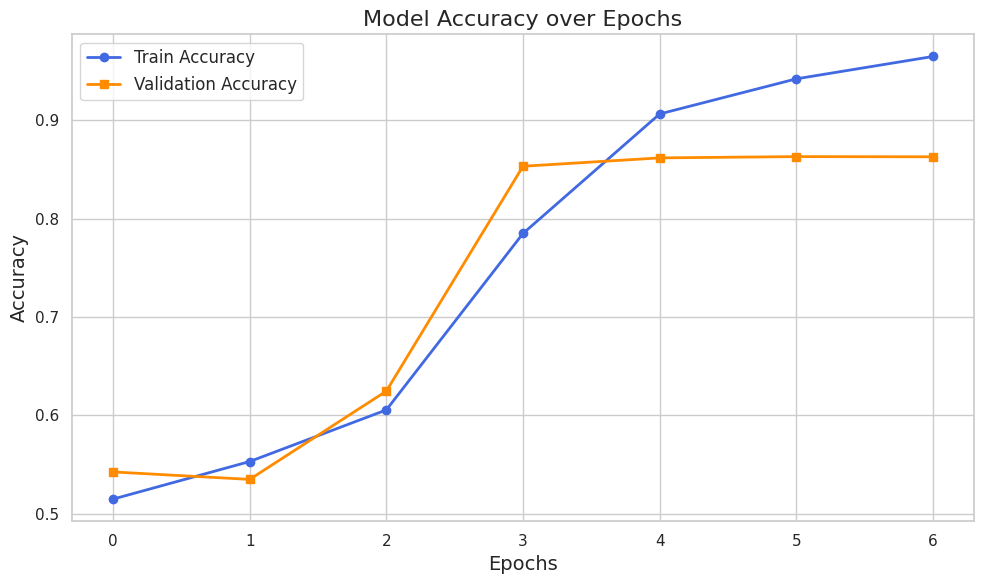

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy', color='royalblue', linewidth=2)
plt.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy', color='darkorange', linewidth=2)

# Enhancements
plt.title('Model Accuracy over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.xticks(range(len(history.history['accuracy'])))
plt.tight_layout()
plt.show()


In [ ]:
pip install transformers datasets tensorflow

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=200),
    Dropout(0.3),  # Regularize embedding
    Conv1D(128, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-4)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5038 - loss: 0.7152 - val_accuracy: 0.6625 - val_loss: 0.7012
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6245 - loss: 0.6855 - val_accuracy: 0.7247 - val_loss: 0.5868
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7480 - loss: 0.5593 - val_accuracy: 0.7905 - val_loss: 0.4719
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8127 - loss: 0.4466 - val_accuracy: 0.8238 - val_loss: 0.4073
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8487 - loss: 0.3798 - val_accuracy: 0.8455 - val_loss: 0.3684
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8760 - loss: 0.3253 - val_accuracy: 0.8572 - val_loss: 0.3453
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9005 - loss: 0.2815 - val_accuracy: 0.8679 - val_loss: 0.3301
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9157 - loss: 0.2462 - val_accuracy: 0

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_val, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



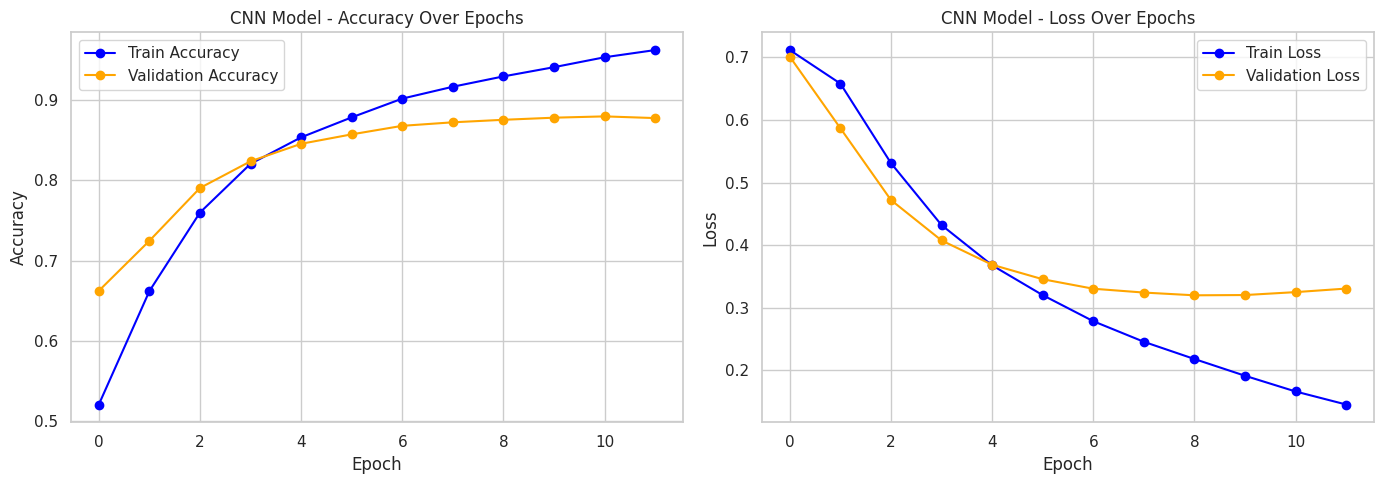

In [ ]:
import matplotlib.pyplot as plt

# Accuracy and Loss plots for CNN model
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title('CNN Model - Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('CNN Model - Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()